In [108]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,accuracy_score
import pickle
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn import datasets
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import kagglehub
from scipy.io import arff
from imblearn.under_sampling import RandomUnderSampler
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata
import warnings
warnings.simplefilter(action='ignore')

Loading dataset : https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

In [109]:
# Download latest version
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\ejeme\.cache\kagglehub\datasets\uciml\breast-cancer-wisconsin-data\versions\2


In [110]:
df = pd.read_csv('C:/Users/ejeme/Documents/breast-cancer.csv')
df['diagnosis'].replace({'M':1, 'B':0}, inplace=True)
df.drop(['id','Unnamed: 32'], axis=1, inplace=True)
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [111]:
print(df.shape)
print('Proportion of 1s:', np.round(df.diagnosis.sum()/df.shape[0],2))

(569, 31)
Proportion of 1s: 0.37


#### some preprocessing

In [112]:
X = df.drop(['diagnosis'], axis=1).sample(2, axis=1, random_state=7)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# If you want a DataFrame back
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

Y = df.diagnosis

In [113]:
Y.sum()/len(Y)

np.float64(0.37258347978910367)

In [114]:
# split
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.5, random_state=0, stratify=Y)

## <font color='yellow'> logistic regression

In [115]:
model = LogisticRegression(random_state=0, max_iter=1000)
model.fit(X_train, Y_train)

LogisticRegression(max_iter=1000, random_state=0)

In [116]:
# On test set after model selection
test_pred = model.predict(X_test)
print(classification_report(Y_test, test_pred))
print('Test Accuracy:', accuracy_score(Y_test, test_pred))

              precision    recall  f1-score   support

           0       0.88      0.92      0.90       179
           1       0.86      0.79      0.82       106

    accuracy                           0.87       285
   macro avg       0.87      0.86      0.86       285
weighted avg       0.87      0.87      0.87       285

Test Accuracy: 0.8736842105263158


### Retrieving $\kappa_f$ confidence function

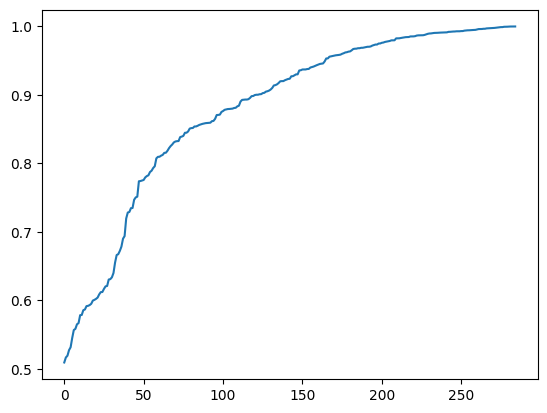

In [117]:
y_true = Y_test
y_pred = test_pred
kappa = model.predict_proba(X_test).max(axis=1)
plt.plot(sorted(kappa))

In [118]:
sgr_df = pd.DataFrame({'y_true': y_true,
                       'y_pred': y_pred,
                       'kappa': kappa}).sort_values('kappa')
sgr_df

,y_true,y_pred,kappa
500,0,1,0.509190
560,0,0,0.516484
227,0,1,0.519066
65,1,1,0.527205
214,1,1,0.531426
...,...,...,...
108,1,1,0.999868
202,1,1,0.999938
122,1,1,0.999942
82,1,1,0.999978


In [119]:
pickle.dump(sgr_df, open('sgr_set_log_reg','wb'))

## <font color='yellow'> MLP

In [120]:
# Scale features 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
Y_test_tensor = torch.tensor(Y_test.values, dtype=torch.float32).view(-1, 1)

# Define  small MLP 
class SmallMLP(nn.Module):
    def __init__(self, input_dim):
        super(SmallMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

# Instantiate model, loss, optimizer
input_dim = X_train_tensor.shape[1]
model = SmallMLP(input_dim)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Train the model
epochs = 60
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, Y_train_tensor)
    loss.backward()
    optimizer.step()

    # Optional: Evaluate on test set
    if epoch % 10 == 0 or epoch == epochs - 1:
        model.eval()
        with torch.no_grad():
            test_preds = model(X_test_tensor)
            test_preds_binary = (test_preds > 0.5).float()
            test_acc = (test_preds_binary == Y_test_tensor).float().mean().item()
            print(f"Epoch {epoch} | Loss: {loss.item():.4f} | Test Acc: {test_acc*100:.2f}%")


Epoch 0 | Loss: 0.7201 | Test Acc: 60.00%
Epoch 10 | Loss: 0.6311 | Test Acc: 63.16%
Epoch 20 | Loss: 0.5592 | Test Acc: 70.88%
Epoch 30 | Loss: 0.4806 | Test Acc: 80.35%
Epoch 40 | Loss: 0.4061 | Test Acc: 83.86%
Epoch 50 | Loss: 0.3469 | Test Acc: 84.91%
Epoch 59 | Loss: 0.3054 | Test Acc: 85.96%


In [121]:
model.eval()
with torch.no_grad():
    test_probs = model(X_test_tensor)  # Shape: (num_samples, 1)
    test_preds = (test_probs > 0.5).float() 

In [122]:
sgr_df = pd.DataFrame({'y_true': Y_test,
                       'y_pred': test_preds.numpy().astype(int).flatten(),
                       'kappa': test_probs.numpy().flatten()}).sort_values('kappa')
sgr_df

,y_true,y_pred,kappa
538,0,0,0.010631
175,0,0,0.014511
192,0,0,0.019655
46,0,0,0.022127
174,0,0,0.027148
...,...,...,...
213,1,1,0.989839
108,1,1,0.990684
202,1,1,0.992912
82,1,1,0.993344


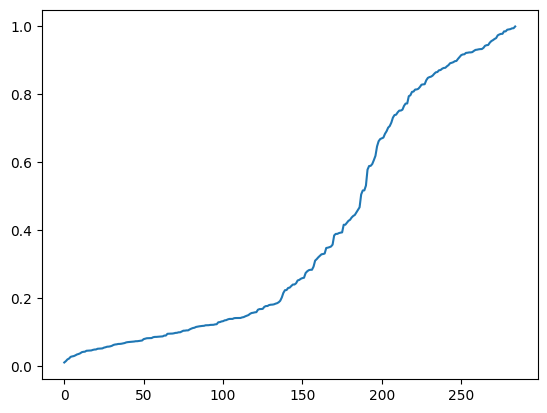

In [123]:
plt.plot(sorted(sgr_df.kappa))
plt.show()

In [124]:
pickle.dump(sgr_df, open('sgr_set_mlp', 'wb'))